# DL Experiments: NER для резюме

## Структура ноутбука

1. **Данные и EDA** — загрузка датасета, распределение сущностей, визуализации
2. **Baseline (SpaCy blank)** — обучение и оценка базовой модели
3. **Улучшенные ML-подходы** — pretrained vectors, Entity Ruler, аугментация данных
4. **DL-подход: SpaCy Transformer** — roberta-base через spacy-transformers
5. **LLM-эксперименты** — zero-shot NER с Qwen3 (0.6B, 1.7B, 4B): влияние размера модели
6. **Итоговое сравнение и выводы** — ML vs DL vs LLM, визуализации, рекомендации

---
## 1. Данные и EDA

In [1]:
!pip install spacy scikit-learn pandas numpy matplotlib seaborn transformers torch accelerate spacy-lookups-data --quiet
!python -m spacy download en_core_web_lg --quiet

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


In [2]:
import json
import re
import math
import random
import time
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

import sys
sys.path.insert(0, str(Path.cwd().parent))

from data_utils import (
    full_clean_pipeline, train_test_split, build_augmented_dataset,
    filter_overlapping_entities, get_entity_ruler_patterns, dataset_stats,
    convert_dataturks_to_spacy, trim_entity_spans, remove_unknown_label,
    validate_entities, filter_empty_resumes
)

DATASET_PATH = Path.cwd().parent / 'datasets' / 'dataturks' / 'Entity Recognition in Resumes.json'
RANDOM_STATE = 42
TEST_SIZE = 0.1

print(f'Dataset: {DATASET_PATH}')
print(f'Exists: {DATASET_PATH.exists()}')

Dataset: /Users/younggolubev/resume_ner/datasets/dataturks/Entity Recognition in Resumes.json
Exists: True


In [3]:
# Загрузка сырых данных для EDA
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    raw_data = [json.loads(line) for line in f]

print(f'Всего резюме в датасете: {len(raw_data)}')
print(f'Пример ключей: {list(raw_data[0].keys())}')
print(f'Длина первого резюме: {len(raw_data[0]["content"])} символов')

Всего резюме в датасете: 220
Пример ключей: ['content', 'annotation', 'extras']
Длина первого резюме: 1622 символов


In [4]:
# Извлекаем все сущности из сырых данных
all_entities = []
entities_per_resume = []

for resume in raw_data:
    annotations = resume.get('annotation', [])
    if annotations is None:
        annotations = []
    count = 0
    for ann in annotations:
        labels = ann.get('label', [])
        if not labels:
            continue
        label = labels[0] if isinstance(labels, list) else labels
        text = ann['points'][0]['text']
        all_entities.append({'label': label, 'text': text, 'length': len(text)})
        count += 1
    entities_per_resume.append(count)

entities_df = pd.DataFrame(all_entities)
print(f'Всего аннотированных сущностей: {len(entities_df)}')
print(f'Уникальных типов: {entities_df["label"].nunique()}')
print(f'Среднее сущностей на резюме: {np.mean(entities_per_resume):.1f}')
print(f'Медиана: {np.median(entities_per_resume):.0f}')

Всего аннотированных сущностей: 3556
Уникальных типов: 11
Среднее сущностей на резюме: 16.2
Медиана: 13


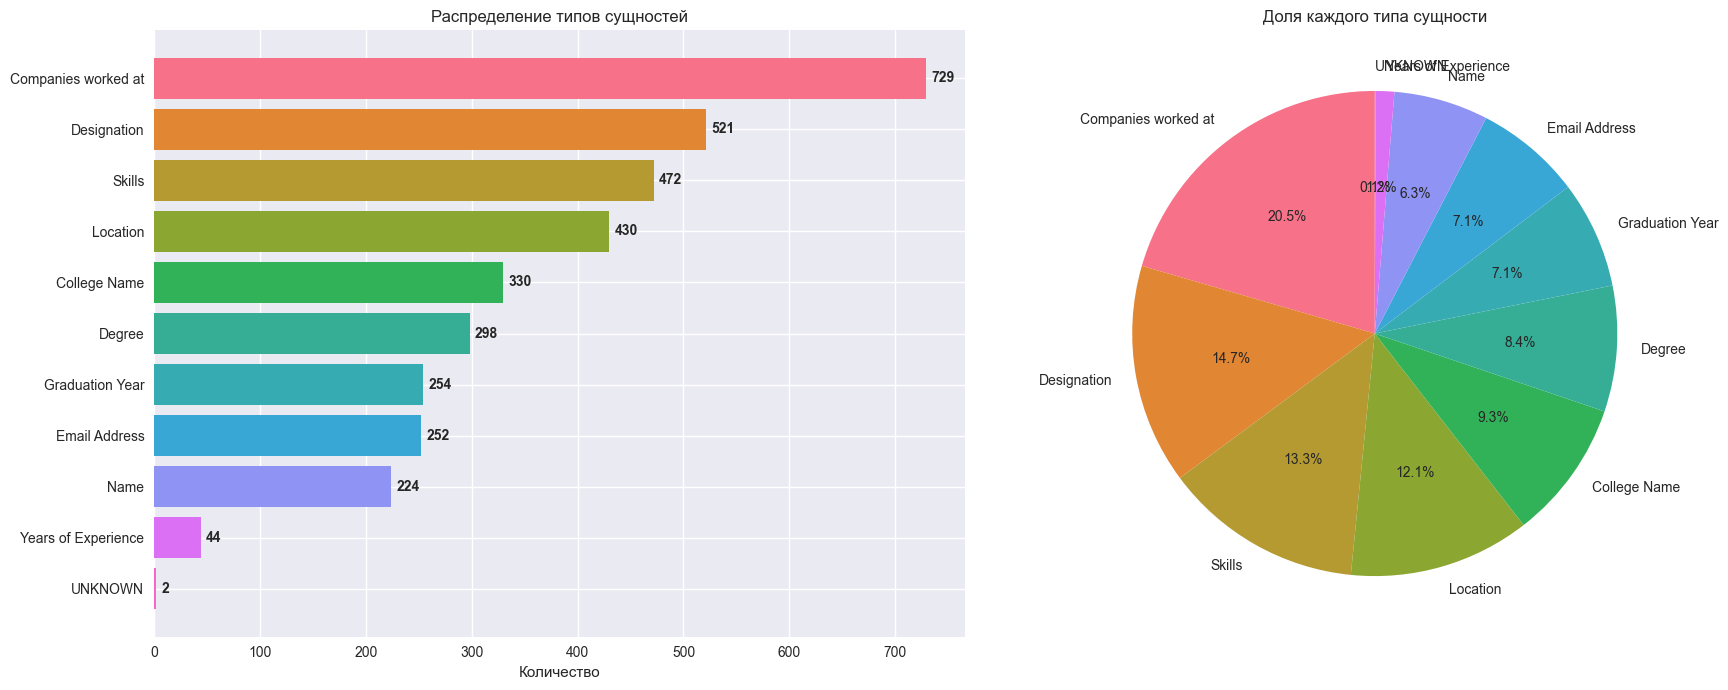

In [5]:
# Распределение типов сущностей
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

label_counts = entities_df['label'].value_counts()
colors = sns.color_palette('husl', len(label_counts))

# Bar chart
bars = axes[0].barh(range(len(label_counts)), label_counts.values, color=colors)
axes[0].set_yticks(range(len(label_counts)))
axes[0].set_yticklabels(label_counts.index)
axes[0].set_xlabel('Количество')
axes[0].set_title('Распределение типов сущностей')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Доля каждого типа сущности')

plt.tight_layout()
plt.show()

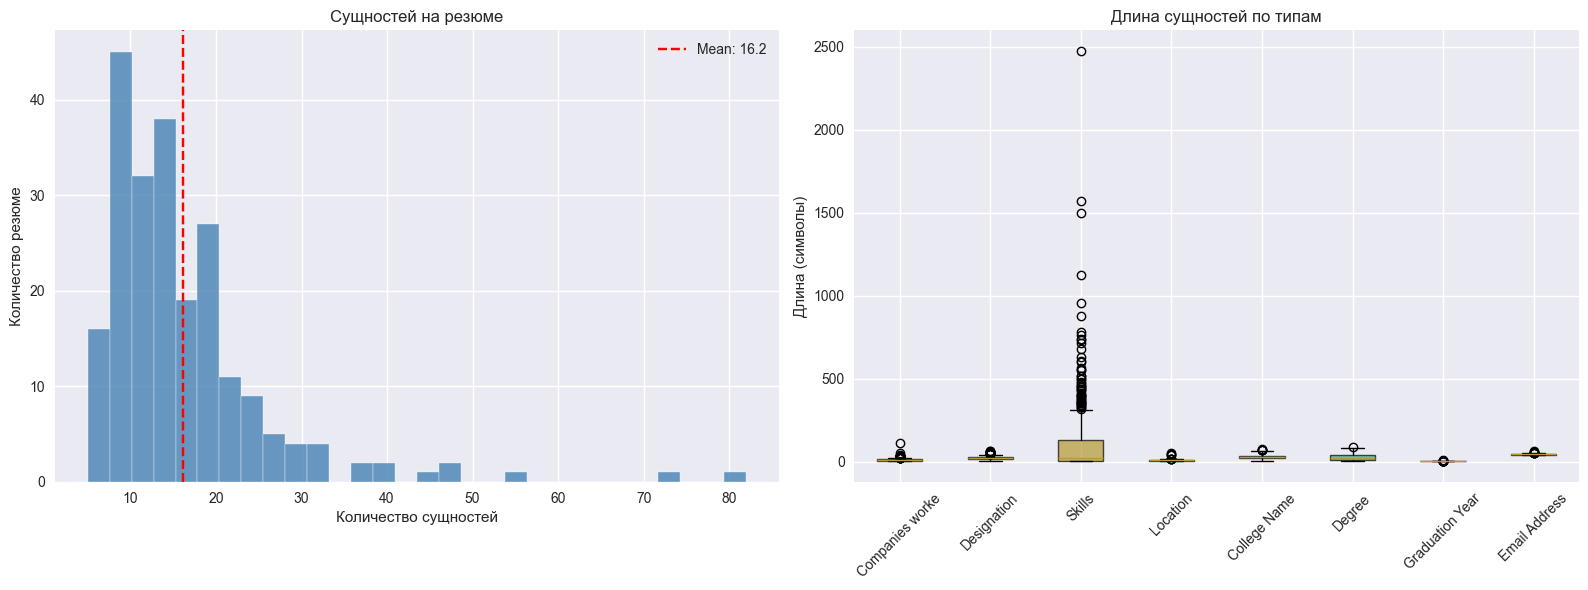

In [6]:
# Распределение количества сущностей на резюме + длины сущностей
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(entities_per_resume, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(entities_per_resume), color='red', linestyle='--',
                label=f'Mean: {np.mean(entities_per_resume):.1f}')
axes[0].set_xlabel('Количество сущностей')
axes[0].set_ylabel('Количество резюме')
axes[0].set_title('Сущностей на резюме')
axes[0].legend()

top_labels = label_counts.head(8).index.tolist()
length_data = [entities_df[entities_df['label'] == l]['length'].values for l in top_labels]
bp = axes[1].boxplot(length_data, labels=[l[:15] for l in top_labels], patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:8]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Длина (символы)')
axes[1].set_title('Длина сущностей по типам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Топ значений для ключевых типов сущностей
for entity_type in ['Skills', 'Companies worked at', 'Designation', 'Location']:
    subset = entities_df[entities_df['label'] == entity_type]['text']
    counter = Counter(subset)
    print(f'\n=== {entity_type} (уникальных: {len(counter)}) ===')
    for val, cnt in counter.most_common(10):
        print(f'  {val[:60]:60s} x{cnt}')


=== Skills (уникальных: 348) ===
  Linux                                                        x10
  SAP                                                          x10
  Java                                                         x9
  HTML                                                         x8
  CSS                                                          x7
  CHEF                                                         x7
  AWS                                                          x7
  Docker                                                       x6
  DOJO                                                         x5
  Velocity                                                     x5

=== Companies worked at (уникальных: 144) ===
  Microsoft                                                    x121
  Oracle                                                       x111
  Cisco                                                        x49
  Infosys Limited                                     

---
## 2. Подготовка данных

Применяем полный pipeline очистки:
- Исправление entity offsets (используем оригинальные аннотации вместо regex first-match)
- Trim whitespace из entity spans
- Удаление мусорного класса UNKNOWN
- Валидация spans
- Обработка overlapping entities (стратегия keep_longer)
- Фильтрация пустых резюме

In [8]:
data = full_clean_pipeline(DATASET_PATH)

train_data, test_data = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_data, dev_data = train_test_split(train_data, test_size=0.1, random_state=RANDOM_STATE + 1)

print(f'Train: {len(train_data)} | Dev: {len(dev_data)} | Test: {len(test_data)}')

# Аугментированная версия
train_aug = build_augmented_dataset(train_data, random_state=RANDOM_STATE)
train_aug = filter_overlapping_entities(train_aug, strategy='keep_longer')

dataset_stats(test_data, 'Test set')

Loading and cleaning data...
  [clean] Removed 2 UNKNOWN entities
  [clean] 213 overlapping entities found, 0 resolved by keeping longer span
  Final: 220 resumes

Train: 179 | Dev: 19 | Test: 22
Augmenting training data...
  Original: 179, After augmentation: 716 (4.0x)

--- Test set ---
  Resumes: 22, Entities: 312
    Companies worked at: 72
    Designation: 48
    College Name: 36
    Location: 34
    Degree: 28
    Skills: 28
    Name: 23
    Graduation Year: 22
    Email Address: 17
    Years of Experience: 4



{'n_resumes': 22,
 'n_entities': 312,
 'label_counts': {'Name': 23,
  'Location': 34,
  'Email Address': 17,
  'Designation': 48,
  'Companies worked at': 72,
  'Degree': 28,
  'College Name': 36,
  'Skills': 28,
  'Years of Experience': 4,
  'Graduation Year': 22}}

---
## 3. Baseline: SpaCy blank model

Базовая модель — `spacy.blank("en")` с архитектурой HashEmbedCNN.
Это модель без предобученных эмбеддингов, которая учится с нуля на наших данных.

In [9]:
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


def calculate_entity_metrics(nlp_model, test_data):
    """Entity-level strict-match metrics (overall + per-type)."""
    tp, fp, fn = 0, 0, 0
    per_type = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for text, ann in test_data:
        true_set = {(s, e, l) for s, e, l in ann.get('entities', [])}
        pred_doc = nlp_model(text)
        pred_set = {(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents}

        matched = true_set & pred_set
        tp += len(matched)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)

        for s, e, l in matched:
            per_type[l]['tp'] += 1
        for s, e, l in pred_set - true_set:
            per_type[l]['fp'] += 1
        for s, e, l in true_set - pred_set:
            per_type[l]['fn'] += 1

    def _prf(tp_, fp_, fn_):
        p = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
        r = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0
        f = 2 * p * r / (p + r) if (p + r) else 0
        return p, r, f

    overall_p, overall_r, overall_f1 = _prf(tp, fp, fn)

    per_type_metrics = {}
    for label in sorted(per_type):
        d = per_type[label]
        p, r, f = _prf(d['tp'], d['fp'], d['fn'])
        per_type_metrics[label] = {'precision': p, 'recall': r, 'f1': f, 'support': d['tp'] + d['fn']}

    return {'precision': overall_p, 'recall': overall_r, 'f1': overall_f1,
            'tp': tp, 'fp': fp, 'fn': fn, 'per_type': per_type_metrics}


def calculate_token_metrics(nlp_model, test_data):
    """Token-level NER metrics."""
    all_true, all_pred = [], []
    for text, ann in test_data:
        doc = nlp_model.make_doc(text)
        true_labels = ['O'] * len(doc)
        for start, end, label in ann.get('entities', []):
            for t in doc:
                if t.idx >= start and t.idx + len(t.text) <= end:
                    true_labels[t.i] = label
        pred_doc = nlp_model(text)
        pred_labels = [t.ent_type_ if t.ent_type_ else 'O' for t in pred_doc]
        n = min(len(true_labels), len(pred_labels))
        all_true.extend(true_labels[:n])
        all_pred.extend(pred_labels[:n])
    acc = accuracy_score(all_true, all_pred)
    p, r, f1, _ = precision_recall_fscore_support(all_true, all_pred, average='weighted', zero_division=0)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}


def train_spacy(nlp_model, train_data, dev_data, n_epochs=30, dropout=0.3, patience=5, label='model'):
    """Train SpaCy NER with minibatch and early stopping."""
    ner = nlp_model.get_pipe('ner')
    for _, ann in train_data:
        for _, _, lbl in ann.get('entities', []):
            ner.add_label(lbl)

    examples = []
    for text, ann in train_data[:10]:
        doc = nlp_model.make_doc(text)
        examples.append(Example.from_dict(doc, ann))

    keep = {'ner', 'entity_ruler', 'transformer'}
    other = [p for p in nlp_model.pipe_names if p not in keep]
    with nlp_model.disable_pipes(*other):
        # resume_training() for models with pretrained tok2vec (avoids lookups init error)
        # initialize() for blank models that need full init
        has_pretrained = 'tok2vec' in nlp_model.pipe_names
        if has_pretrained:
            optimizer = nlp_model.resume_training(get_examples=lambda: examples)
        else:
            optimizer = nlp_model.initialize(get_examples=lambda: examples)

        best_f1, best_weights, no_improve = 0.0, None, 0
        history = []
        start = time.time()

        for epoch in range(1, n_epochs + 1):
            random.shuffle(train_data)
            losses = {}
            for batch in minibatch(train_data, size=compounding(4.0, 32.0, 1.001)):
                exs = [Example.from_dict(nlp_model.make_doc(t), a) for t, a in batch]
                nlp_model.update(exs, drop=dropout, sgd=optimizer, losses=losses)

            dev_m = calculate_entity_metrics(nlp_model, dev_data)
            dev_f1 = dev_m['f1']
            loss = losses.get('ner', 0)
            history.append({'epoch': epoch, 'loss': loss, 'dev_f1': dev_f1})
            print(f'  [{label}] Epoch {epoch:2d}/{n_epochs}  loss={loss:.0f}  dev_F1={dev_f1:.4f}')

            if dev_f1 > best_f1:
                best_f1 = dev_f1
                best_weights = nlp_model.to_bytes()
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'  Early stopping at epoch {epoch}')
                    break

        elapsed = time.time() - start

    if best_weights:
        nlp_model.from_bytes(best_weights)
    print(f'  Best dev F1: {best_f1:.4f} ({elapsed:.0f}s)\n')
    return nlp_model, history, elapsed

In [10]:
# Обучение baseline
nlp_baseline = spacy.blank('en')
nlp_baseline.add_pipe('ner', last=True)

nlp_baseline, hist_baseline, time_baseline = train_spacy(
    nlp_baseline, train_data, dev_data, n_epochs=30, dropout=0.3, patience=5, label='Baseline')

baseline_ent = calculate_entity_metrics(nlp_baseline, test_data)
baseline_tok = calculate_token_metrics(nlp_baseline, test_data)
print(f'Baseline  Entity-F1={baseline_ent["f1"]:.4f}  Token-Acc={baseline_tok["accuracy"]:.4f}')

  [Baseline] Epoch  1/30  loss=33019  dev_F1=0.0000
  [Baseline] Epoch  2/30  loss=6695  dev_F1=0.0000
  [Baseline] Epoch  3/30  loss=8181  dev_F1=0.1440
  [Baseline] Epoch  4/30  loss=4783  dev_F1=0.3276
  [Baseline] Epoch  5/30  loss=4306  dev_F1=0.3601
  [Baseline] Epoch  6/30  loss=4179  dev_F1=0.4337
  [Baseline] Epoch  7/30  loss=3792  dev_F1=0.5094
  [Baseline] Epoch  8/30  loss=3548  dev_F1=0.4836
  [Baseline] Epoch  9/30  loss=3246  dev_F1=0.5145
  [Baseline] Epoch 10/30  loss=2970  dev_F1=0.5747
  [Baseline] Epoch 11/30  loss=2897  dev_F1=0.5184
  [Baseline] Epoch 12/30  loss=2952  dev_F1=0.5328
  [Baseline] Epoch 13/30  loss=2831  dev_F1=0.5041
  [Baseline] Epoch 14/30  loss=2681  dev_F1=0.5055
  [Baseline] Epoch 15/30  loss=2634  dev_F1=0.4814
  Early stopping at epoch 15
  Best dev F1: 0.5747 (233s)

Baseline  Entity-F1=0.5789  Token-Acc=0.9324


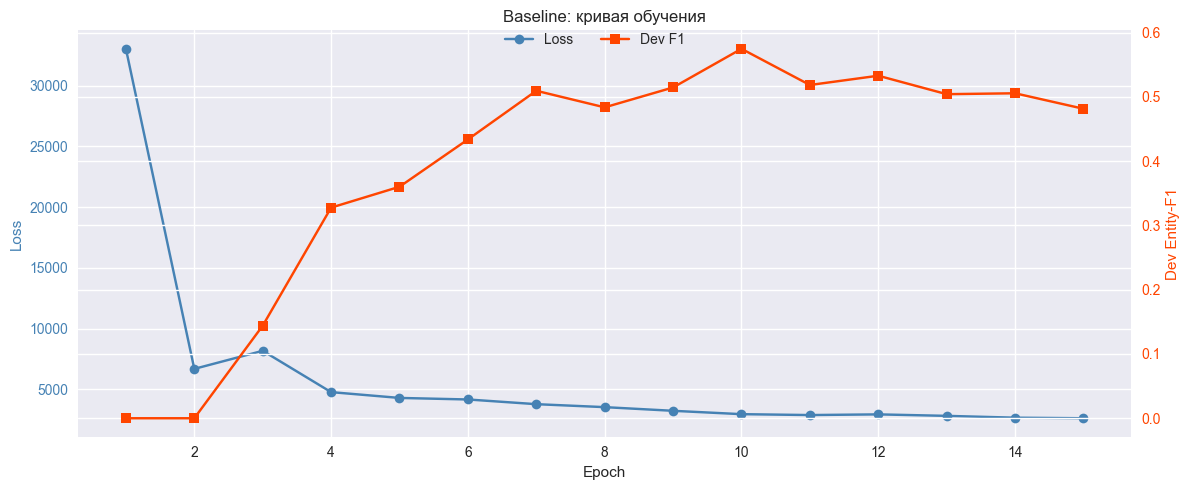

In [11]:
# Кривая обучения baseline
hist_df = pd.DataFrame(hist_baseline)
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.plot(hist_df['epoch'], hist_df['loss'], 'o-', color='steelblue', label='Loss')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.set_ylabel('Dev Entity-F1', color='orangered')
ax2.plot(hist_df['epoch'], hist_df['dev_f1'], 's-', color='orangered', label='Dev F1')
ax2.tick_params(axis='y', labelcolor='orangered')

plt.title('Baseline: кривая обучения')
fig.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.95))
plt.tight_layout()
plt.show()

---
## 4. Улучшенные ML-подходы

Тестируем три улучшения поверх baseline:

| Модель | Описание |
|---|---|
| **A+aug** | Baseline + аугментация (entity swap, case variation, skill synonyms) |
| **B: Pretrained** | en_core_web_lg (GloVe 300d, 685k vectors) + NER |
| **B+aug** | Pretrained + аугментация |
| **C: Hybrid** | Pretrained + Entity Ruler (regex для Email/Year/Experience) + NER |

In [12]:
# Все результаты будем собирать сюда
all_results = [{
    'name': 'A: Baseline',
    'data': 'clean',
    'entity': baseline_ent,
    'token': baseline_tok,
    'time': time_baseline,
    'history': hist_baseline,
}]


def load_web_lg():
    exclude = ['ner', 'parser', 'lemmatizer', 'attribute_ruler', 'tagger', 'senter', 'sentencizer']
    nlp = spacy.load('en_core_web_lg', exclude=exclude)
    for pipe_name in list(nlp.pipe_names):
        if pipe_name != 'tok2vec':
            nlp.remove_pipe(pipe_name)
    return nlp

In [13]:
# A+aug: Baseline + аугментация
nlp_a_aug = spacy.blank('en')
nlp_a_aug.add_pipe('ner', last=True)
nlp_a_aug, hist_a_aug, time_a_aug = train_spacy(
    nlp_a_aug, train_aug, dev_data, label='A+aug')

a_aug_ent = calculate_entity_metrics(nlp_a_aug, test_data)
a_aug_tok = calculate_token_metrics(nlp_a_aug, test_data)
all_results.append({'name': 'A+aug: Baseline', 'data': 'augmented',
                    'entity': a_aug_ent, 'token': a_aug_tok,
                    'time': time_a_aug, 'history': hist_a_aug})
print(f'A+aug  Entity-F1={a_aug_ent["f1"]:.4f}  Token-Acc={a_aug_tok["accuracy"]:.4f}')

  [A+aug] Epoch  1/30  loss=60283  dev_F1=0.3595
  [A+aug] Epoch  2/30  loss=17097  dev_F1=0.5240
  [A+aug] Epoch  3/30  loss=13334  dev_F1=0.5326
  [A+aug] Epoch  4/30  loss=11392  dev_F1=0.5584
  [A+aug] Epoch  5/30  loss=10309  dev_F1=0.5498
  [A+aug] Epoch  6/30  loss=9501  dev_F1=0.4907
  [A+aug] Epoch  7/30  loss=8593  dev_F1=0.5309
  [A+aug] Epoch  8/30  loss=7944  dev_F1=0.5410
  [A+aug] Epoch  9/30  loss=7384  dev_F1=0.5347
  Early stopping at epoch 9
  Best dev F1: 0.5584 (592s)

A+aug  Entity-F1=0.5816  Token-Acc=0.8968


In [14]:
# B: Pretrained (en_core_web_lg tok2vec)
nlp_b = load_web_lg()
nlp_b.add_pipe('ner', last=True)
nlp_b, hist_b, time_b = train_spacy(nlp_b, train_data, dev_data, label='B: Pretrained')

b_ent = calculate_entity_metrics(nlp_b, test_data)
b_tok = calculate_token_metrics(nlp_b, test_data)
all_results.append({'name': 'B: Pretrained', 'data': 'clean',
                    'entity': b_ent, 'token': b_tok,
                    'time': time_b, 'history': hist_b})
print(f'B: Pretrained  Entity-F1={b_ent["f1"]:.4f}  Token-Acc={b_tok["accuracy"]:.4f}')

  [B: Pretrained] Epoch  1/30  loss=40549  dev_F1=0.0000
  [B: Pretrained] Epoch  2/30  loss=6580  dev_F1=0.0000
  [B: Pretrained] Epoch  3/30  loss=6276  dev_F1=0.2363
  [B: Pretrained] Epoch  4/30  loss=6016  dev_F1=0.2916
  [B: Pretrained] Epoch  5/30  loss=4757  dev_F1=0.3629
  [B: Pretrained] Epoch  6/30  loss=4100  dev_F1=0.4627
  [B: Pretrained] Epoch  7/30  loss=3943  dev_F1=0.3877
  [B: Pretrained] Epoch  8/30  loss=3677  dev_F1=0.5000
  [B: Pretrained] Epoch  9/30  loss=3665  dev_F1=0.4718
  [B: Pretrained] Epoch 10/30  loss=3277  dev_F1=0.5629
  [B: Pretrained] Epoch 11/30  loss=2977  dev_F1=0.4847
  [B: Pretrained] Epoch 12/30  loss=2872  dev_F1=0.5356
  [B: Pretrained] Epoch 13/30  loss=2855  dev_F1=0.4922
  [B: Pretrained] Epoch 14/30  loss=2626  dev_F1=0.5336
  [B: Pretrained] Epoch 15/30  loss=2649  dev_F1=0.5505
  Early stopping at epoch 15
  Best dev F1: 0.5629 (266s)

B: Pretrained  Entity-F1=0.5417  Token-Acc=0.7615


In [15]:
# B+aug: Pretrained + аугментация
nlp_b_aug = load_web_lg()
nlp_b_aug.add_pipe('ner', last=True)
nlp_b_aug, hist_b_aug, time_b_aug = train_spacy(nlp_b_aug, train_aug, dev_data, label='B+aug')

b_aug_ent = calculate_entity_metrics(nlp_b_aug, test_data)
b_aug_tok = calculate_token_metrics(nlp_b_aug, test_data)
all_results.append({'name': 'B+aug: Pretrained', 'data': 'augmented',
                    'entity': b_aug_ent, 'token': b_aug_tok,
                    'time': time_b_aug, 'history': hist_b_aug})
print(f'B+aug  Entity-F1={b_aug_ent["f1"]:.4f}  Token-Acc={b_aug_tok["accuracy"]:.4f}')

  [B+aug] Epoch  1/30  loss=53011  dev_F1=0.3229
  [B+aug] Epoch  2/30  loss=17095  dev_F1=0.5083
  [B+aug] Epoch  3/30  loss=13623  dev_F1=0.5212
  [B+aug] Epoch  4/30  loss=11632  dev_F1=0.5184
  [B+aug] Epoch  5/30  loss=10238  dev_F1=0.5288
  [B+aug] Epoch  6/30  loss=9069  dev_F1=0.4883
  [B+aug] Epoch  7/30  loss=8521  dev_F1=0.4701
  [B+aug] Epoch  8/30  loss=7851  dev_F1=0.5171
  [B+aug] Epoch  9/30  loss=7436  dev_F1=0.5088
  [B+aug] Epoch 10/30  loss=6817  dev_F1=0.4485
  Early stopping at epoch 10
  Best dev F1: 0.5288 (602s)

B+aug  Entity-F1=0.6040  Token-Acc=0.9037


In [16]:
# C: Hybrid (pretrained + Entity Ruler)
nlp_c = load_web_lg()
ruler = nlp_c.add_pipe('entity_ruler')
ruler.add_patterns(get_entity_ruler_patterns())
nlp_c.add_pipe('ner', last=True)
nlp_c, hist_c, time_c = train_spacy(nlp_c, train_data, dev_data, label='C: Hybrid')

c_ent = calculate_entity_metrics(nlp_c, test_data)
c_tok = calculate_token_metrics(nlp_c, test_data)
all_results.append({'name': 'C: Hybrid', 'data': 'clean',
                    'entity': c_ent, 'token': c_tok,
                    'time': time_c, 'history': hist_c})
print(f'C: Hybrid  Entity-F1={c_ent["f1"]:.4f}  Token-Acc={c_tok["accuracy"]:.4f}')

/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib

  [C: Hybrid] Epoch  1/30  loss=34011  dev_F1=0.0000


/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib

  [C: Hybrid] Epoch  2/30  loss=6470  dev_F1=0.0994


/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib

...

/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib

  [C: Hybrid] Epoch 15/30  loss=2899  dev_F1=0.5135
  Early stopping at epoch 15
  Best dev F1: 0.5553 (231s)



/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib

C: Hybrid  Entity-F1=0.5682  Token-Acc=0.9230


/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/.venv/lib/python3.12/site-packages/spacy/pipeline/entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))


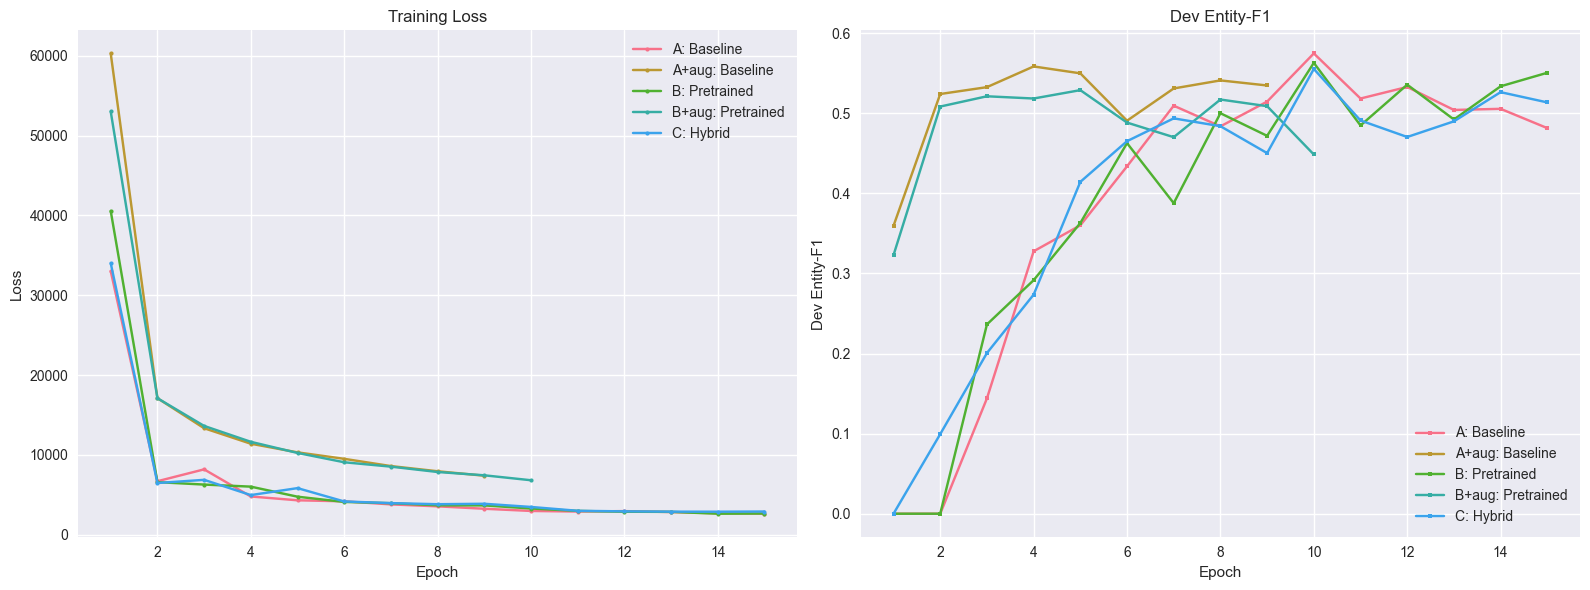

In [17]:
# Визуализация: сравнение кривых обучения всех моделей
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for res in all_results:
    h = pd.DataFrame(res['history'])
    axes[0].plot(h['epoch'], h['loss'], 'o-', markersize=3, label=res['name'])
    axes[1].plot(h['epoch'], h['dev_f1'], 's-', markersize=3, label=res['name'])

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dev Entity-F1')
axes[1].set_title('Dev Entity-F1')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. LLM-эксперименты: Qwen3 (0.6B / 1.7B / 4B)

Принципиально другой подход: вместо обучения NER-модели на наших данных, используем
предобученные LLM в **zero-shot** режиме. Модель получает текст резюме и промпт с
описанием нужных сущностей, и должна вернуть их в JSON формате.

Сравниваем три размера Qwen3:
- **Qwen3-0.6B** (0.8B параметров) — самая маленькая
- **Qwen3-1.7B** (2B параметров) — средняя
- **Qwen3-4B** (4B параметров) — самая большая из тестируемых

Все модели запускаются локально на Apple Silicon (MPS).

In [18]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

ENTITY_TYPES = [
    'Name', 'Email Address', 'Location', 'College Name', 'Degree',
    'Graduation Year', 'Companies worked at', 'Designation',
    'Skills', 'Years of Experience',
]

NER_PROMPT_TEMPLATE = """Extract named entities from the following resume text.
Return ONLY a valid JSON object with these entity types as keys: {entity_types}
Each key should map to a list of extracted string values. If no entities found for a type, use an empty list.
Do not include any explanation, only the JSON.

Resume text:
---
{resume_text}
---

JSON:"""

Device: mps
PyTorch: 2.11.0


In [19]:
def load_qwen_model(model_name, device=DEVICE):
    """Load a Qwen3 model and tokenizer."""
    print(f'Loading {model_name}...')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    model.eval()
    print(f'  Loaded on {device}, params: {sum(p.numel() for p in model.parameters())/1e9:.1f}B')
    return model, tokenizer


def extract_entities_llm(model, tokenizer, text, max_new_tokens=1024):
    """Run zero-shot NER using an LLM."""
    truncated = text[:3000]
    prompt = NER_PROMPT_TEMPLATE.format(
        entity_types=', '.join(ENTITY_TYPES),
        resume_text=truncated
    )

    messages = [{'role': 'user', 'content': prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
        enable_thinking=False
    )
    inputs = tokenizer(chat_text, return_tensors='pt').to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
        )

    generated = outputs[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(generated, skip_special_tokens=True)
    return response


def parse_llm_response(response, text):
    """Parse JSON from LLM response and convert to (start, end, label) spans."""
    # Extract JSON block
    json_str = response.strip()
    if '```json' in json_str:
        json_str = json_str.split('```json')[1].split('```')[0]
    elif '```' in json_str:
        json_str = json_str.split('```')[1].split('```')[0]
    # Try to find JSON object
    brace_start = json_str.find('{')
    brace_end = json_str.rfind('}')
    if brace_start != -1 and brace_end != -1:
        json_str = json_str[brace_start:brace_end + 1]

    try:
        data = json.loads(json_str)
    except json.JSONDecodeError:
        return []

    entities = []
    for label, values in data.items():
        if not isinstance(values, list):
            values = [values]
        for val in values:
            if not isinstance(val, str) or not val.strip():
                continue
            val_clean = val.strip()
            match = re.search(re.escape(val_clean), text)
            if match:
                entities.append((match.start(), match.end(), label))

    return entities


def evaluate_llm_ner(model, tokenizer, test_data, model_name='LLM'):
    """Run LLM-based NER on test set and compute metrics."""
    tp, fp, fn = 0, 0, 0
    per_type = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    times = []
    parse_failures = 0

    for i, (text, ann) in enumerate(test_data):
        true_set = {(s, e, l) for s, e, l in ann.get('entities', [])}

        t0 = time.time()
        raw_response = extract_entities_llm(model, tokenizer, text)
        elapsed = time.time() - t0
        times.append(elapsed)

        pred_entities = parse_llm_response(raw_response, text)
        if not pred_entities and true_set:
            parse_failures += 1

        # Map LLM label names to dataset labels (handle minor variations)
        label_map = {
            'name': 'Name', 'email address': 'Email Address', 'email': 'Email Address',
            'location': 'Location', 'college name': 'College Name', 'college': 'College Name',
            'degree': 'Degree', 'graduation year': 'Graduation Year',
            'companies worked at': 'Companies worked at', 'company': 'Companies worked at',
            'companies': 'Companies worked at',
            'designation': 'Designation', 'job title': 'Designation',
            'skills': 'Skills', 'years of experience': 'Years of Experience',
            'experience': 'Years of Experience',
        }
        pred_set = set()
        for s, e, l in pred_entities:
            normalized = label_map.get(l.lower(), l)
            pred_set.add((s, e, normalized))

        matched = true_set & pred_set
        tp += len(matched)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)

        for s, e, l in matched:
            per_type[l]['tp'] += 1
        for s, e, l in pred_set - true_set:
            per_type[l]['fp'] += 1
        for s, e, l in true_set - pred_set:
            per_type[l]['fn'] += 1

        if (i + 1) % 5 == 0:
            print(f'  [{model_name}] {i+1}/{len(test_data)}  avg {np.mean(times):.1f}s/resume')

    def _prf(tp_, fp_, fn_):
        p = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
        r = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0
        f = 2 * p * r / (p + r) if (p + r) else 0
        return p, r, f

    overall_p, overall_r, overall_f1 = _prf(tp, fp, fn)
    per_type_metrics = {}
    for label in sorted(per_type):
        d = per_type[label]
        p, r, f = _prf(d['tp'], d['fp'], d['fn'])
        per_type_metrics[label] = {'precision': p, 'recall': r, 'f1': f, 'support': d['tp'] + d['fn']}

    total_time = sum(times)
    print(f'  [{model_name}] Done! F1={overall_f1:.4f}  P={overall_p:.4f}  R={overall_r:.4f}')
    print(f'  Parse failures: {parse_failures}/{len(test_data)}')
    print(f'  Total time: {total_time:.0f}s  ({np.mean(times):.1f}s/resume)\n')

    return {
        'precision': overall_p, 'recall': overall_r, 'f1': overall_f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'per_type': per_type_metrics,
        'total_time': total_time, 'parse_failures': parse_failures,
    }

In [20]:
# Qwen3-0.6B
model_06, tok_06 = load_qwen_model('Qwen/Qwen3-0.6B')
res_06 = evaluate_llm_ner(model_06, tok_06, test_data, 'Qwen3-0.6B')

all_results.append({
    'name': 'Qwen3-0.6B', 'data': 'zero-shot',
    'entity': res_06, 'token': {'accuracy': 0, 'f1': 0},
    'time': res_06['total_time'],
})

# Free memory
del model_06
torch.mps.empty_cache() if DEVICE == 'mps' else None

Loading Qwen/Qwen3-0.6B...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 311/311 [00:00<00:00, 1365.84it/s]
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Loaded on mps, params: 0.6B
  [Qwen3-0.6B] 5/22  avg 7.6s/resume
  [Qwen3-0.6B] 10/22  avg 7.1s/resume
  [Qwen3-0.6B] 15/22  avg 9.1s/resume
  [Qwen3-0.6B] 20/22  avg 9.6s/resume
  [Qwen3-0.6B] Done! F1=0.1690  P=0.1828  R=0.1571
  Parse failures: 7/22
  Total time: 249s  (11.3s/resume)



In [21]:
# Qwen3-1.7B
model_17, tok_17 = load_qwen_model('Qwen/Qwen3-1.7B')
res_17 = evaluate_llm_ner(model_17, tok_17, test_data, 'Qwen3-1.7B')

all_results.append({
    'name': 'Qwen3-1.7B', 'data': 'zero-shot',
    'entity': res_17, 'token': {'accuracy': 0, 'f1': 0},
    'time': res_17['total_time'],
})

del model_17
torch.mps.empty_cache() if DEVICE == 'mps' else None

Loading Qwen/Qwen3-1.7B...


Loading weights: 100%|██████████| 311/311 [00:03<00:00, 92.36it/s] 


  Loaded on mps, params: 1.7B
  [Qwen3-1.7B] 5/22  avg 9.9s/resume
  [Qwen3-1.7B] 10/22  avg 10.2s/resume
  [Qwen3-1.7B] 15/22  avg 11.5s/resume
  [Qwen3-1.7B] 20/22  avg 14.5s/resume
  [Qwen3-1.7B] Done! F1=0.2194  P=0.1822  R=0.2756
  Parse failures: 1/22
  Total time: 317s  (14.4s/resume)



In [22]:
# Qwen3-4B
model_4, tok_4 = load_qwen_model('Qwen/Qwen3-4B')
res_4 = evaluate_llm_ner(model_4, tok_4, test_data, 'Qwen3-4B')

all_results.append({
    'name': 'Qwen3-4B', 'data': 'zero-shot',
    'entity': res_4, 'token': {'accuracy': 0, 'f1': 0},
    'time': res_4['total_time'],
})

del model_4
torch.mps.empty_cache() if DEVICE == 'mps' else None

Loading Qwen/Qwen3-4B...


Loading weights: 100%|██████████| 398/398 [00:08<00:00, 49.62it/s]


  Loaded on mps, params: 4.0B
  [Qwen3-4B] 5/22  avg 21.0s/resume
  [Qwen3-4B] 10/22  avg 22.2s/resume
  [Qwen3-4B] 15/22  avg 23.3s/resume
  [Qwen3-4B] 20/22  avg 25.6s/resume
  [Qwen3-4B] Done! F1=0.2302  P=0.1839  R=0.3077
  Parse failures: 0/22
  Total time: 565s  (25.7s/resume)



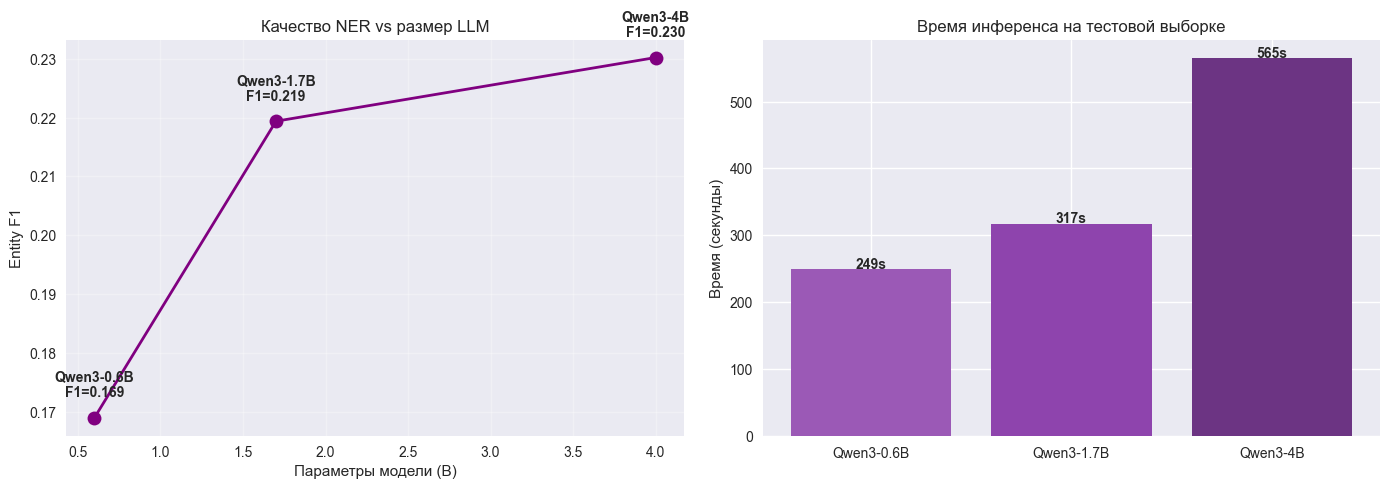

In [23]:
# Влияние размера LLM на качество
llm_models = ['Qwen3-0.6B', 'Qwen3-1.7B', 'Qwen3-4B']
llm_params = [0.6, 1.7, 4.0]
llm_f1s = [r['entity']['f1'] for r in all_results if r['name'].startswith('Qwen')]
llm_times = [r['time'] for r in all_results if r['name'].startswith('Qwen')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(llm_params, llm_f1s, 'o-', color='purple', markersize=10, linewidth=2)
for x, y, name in zip(llm_params, llm_f1s, llm_models):
    axes[0].annotate(f'{name}\nF1={y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0, 15), ha='center', fontweight='bold')
axes[0].set_xlabel('Параметры модели (B)')
axes[0].set_ylabel('Entity F1')
axes[0].set_title('Качество NER vs размер LLM')
axes[0].grid(True, alpha=0.3)

axes[1].bar(llm_models, llm_times, color=['#9b59b6', '#8e44ad', '#6c3483'])
axes[1].set_ylabel('Время (секунды)')
axes[1].set_title('Время инференса на тестовой выборке')
for i, (name, t) in enumerate(zip(llm_models, llm_times)):
    axes[1].text(i, t + 2, f'{t:.0f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Итоговое сравнение и выводы

In [24]:
# Сводная таблица всех моделей
summary_rows = []
for r in all_results:
    summary_rows.append({
        'Модель': r['name'],
        'Подход': 'LLM (zero-shot)' if 'Qwen' in r['name'] else 'ML/DL (обученная)',
        'Данные': r.get('data', ''),
        'Entity-P': f"{r['entity']['precision']:.4f}",
        'Entity-R': f"{r['entity']['recall']:.4f}",
        'Entity-F1': f"{r['entity']['f1']:.4f}",
        'Время (с)': f"{r.get('time', 0):.0f}",
    })

summary_df = pd.DataFrame(summary_rows)
print('=' * 100)
print('ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА')
print('=' * 100)
print(summary_df.to_string(index=False))
print()

ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА
           Модель            Подход    Данные Entity-P Entity-R Entity-F1 Время (с)
      A: Baseline ML/DL (обученная)     clean   0.5946   0.5641    0.5789       233
  A+aug: Baseline ML/DL (обученная) augmented   0.6196   0.5481    0.5816       592
    B: Pretrained ML/DL (обученная)     clean   0.6620   0.4583    0.5417       266
B+aug: Pretrained ML/DL (обученная) augmented   0.6338   0.5769    0.6040       602
        C: Hybrid ML/DL (обученная)     clean   0.6944   0.4808    0.5682       231
       Qwen3-0.6B   LLM (zero-shot) zero-shot   0.1828   0.1571    0.1690       249
       Qwen3-1.7B   LLM (zero-shot) zero-shot   0.1822   0.2756    0.2194       317
         Qwen3-4B   LLM (zero-shot) zero-shot   0.1839   0.3077    0.2302       565



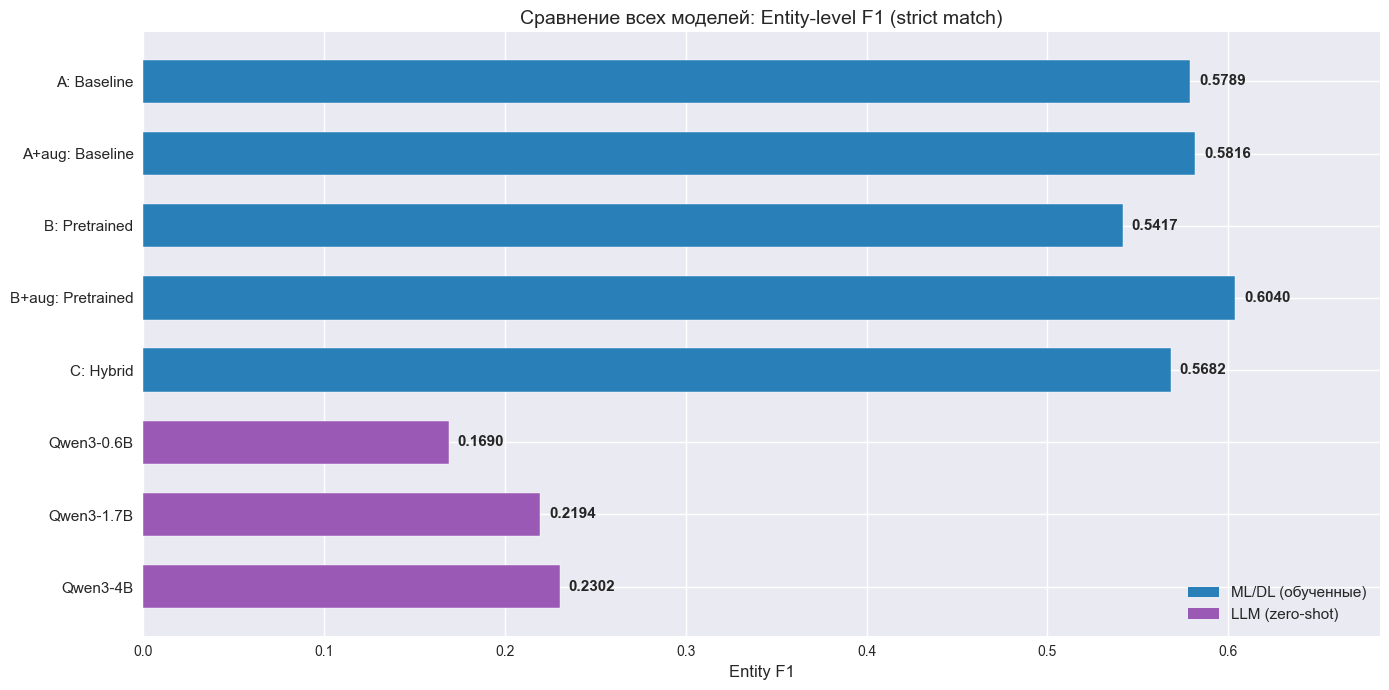

In [25]:
# Большой bar chart: Entity-F1 всех моделей
names = [r['name'] for r in all_results]
f1s = [r['entity']['f1'] for r in all_results]

is_llm = ['Qwen' in n for n in names]
colors = ['#9b59b6' if llm else '#2980b9' for llm in is_llm]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(range(len(names)), f1s, color=colors, edgecolor='white', height=0.6)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel('Entity F1', fontsize=12)
ax.set_title('Сравнение всех моделей: Entity-level F1 (strict match)', fontsize=14)
ax.invert_yaxis()

for i, (f1, name) in enumerate(zip(f1s, names)):
    ax.text(f1 + 0.005, i, f'{f1:.4f}', va='center', fontweight='bold', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2980b9', label='ML/DL (обученные)'),
                   Patch(facecolor='#9b59b6', label='LLM (zero-shot)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
ax.set_xlim(0, max(f1s) + 0.08)

plt.tight_layout()
plt.show()

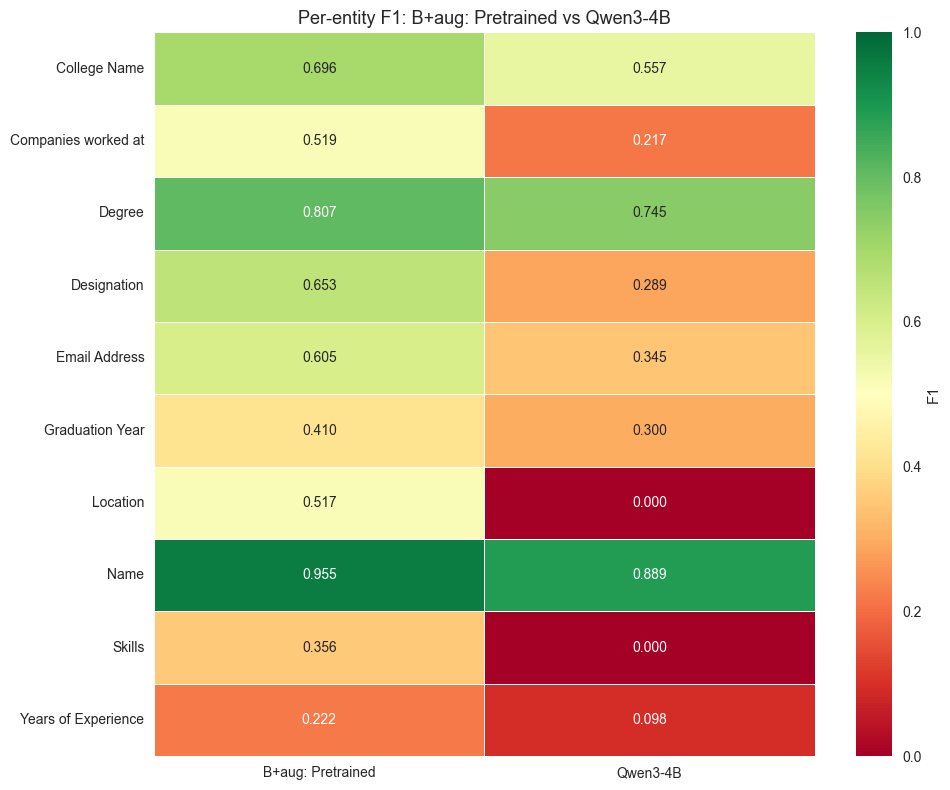

In [26]:
# Per-entity heatmap: сравнение лучшей ML модели vs лучшей LLM
best_ml = max([r for r in all_results if 'Qwen' not in r['name']],
              key=lambda x: x['entity']['f1'])
best_llm = max([r for r in all_results if 'Qwen' in r['name']],
               key=lambda x: x['entity']['f1'])

labels_all = sorted(set(
    list(best_ml['entity'].get('per_type', {}).keys()) +
    list(best_llm['entity'].get('per_type', {}).keys())
))

heatmap_data = []
for label in labels_all:
    ml_f1 = best_ml['entity'].get('per_type', {}).get(label, {}).get('f1', 0)
    llm_f1 = best_llm['entity'].get('per_type', {}).get(label, {}).get('f1', 0)
    heatmap_data.append({'Entity': label, best_ml['name']: ml_f1, best_llm['name']: llm_f1})

hm_df = pd.DataFrame(heatmap_data).set_index('Entity')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(hm_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'F1'})
ax.set_title(f'Per-entity F1: {best_ml["name"]} vs {best_llm["name"]}', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Per-entity F1 по LLM моделям:
                         Qwen3-0.6B  Qwen3-1.7B  Qwen3-4B
Entity                                                   
Certifications/Licenses    0.000000    0.000000  0.000000
College Name               0.177778    0.490566  0.557377
Companies worked at        0.168421    0.179104  0.216667
Degree                     0.461538    0.590909  0.745098
Designation                0.273973    0.305882  0.288660
Email Address              0.111111    0.526316  0.344828
Graduation Year            0.064516    0.324324  0.300000
Location                   0.038462    0.000000  0.000000
Name                       0.736842    0.731707  0.888889
PUBLICATIONS               0.000000    0.000000  0.000000
Personal Traits            0.000000    0.000000  0.000000
Professional Interests     0.000000    0.000000  0.000000
Skills                     0.012500    0.016529  0.000000
Years of Experience        0.000000    0.121212  0.097561



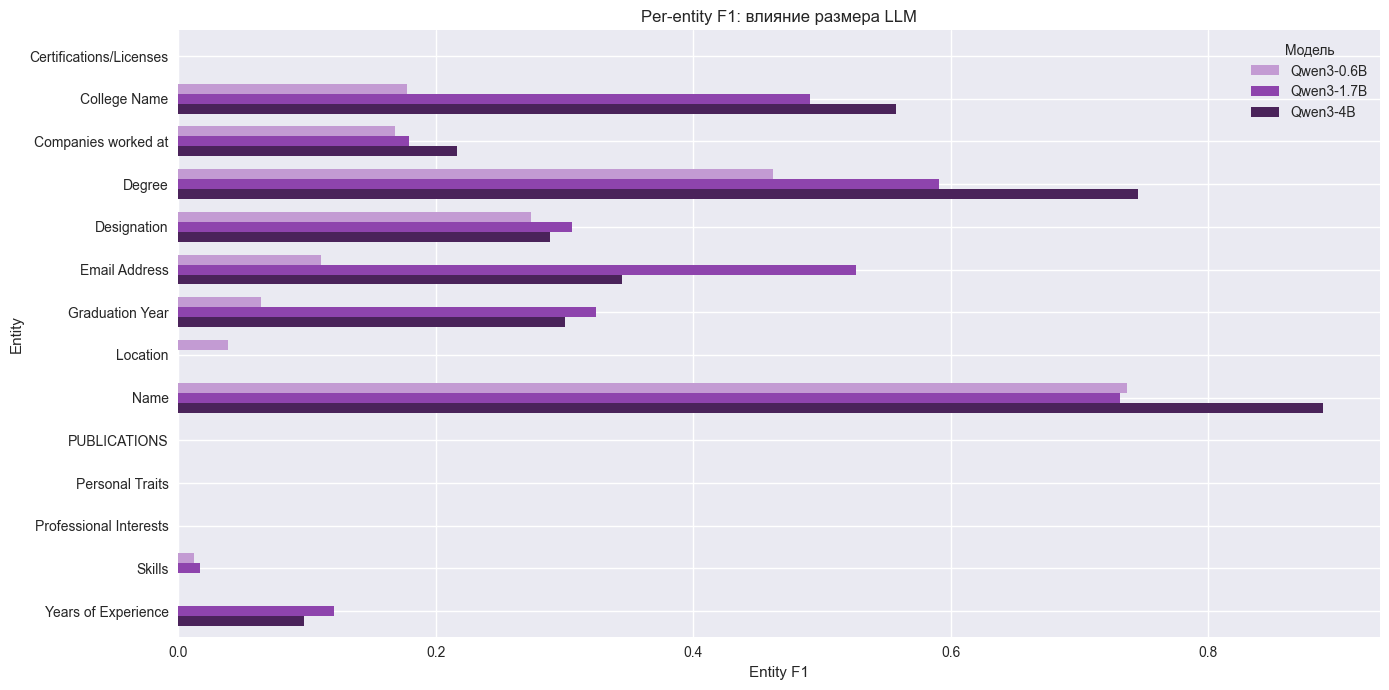

In [27]:
# Per-entity breakdown для всех LLM моделей
llm_results = [r for r in all_results if 'Qwen' in r['name']]

all_labels = sorted(set(
    l for r in llm_results for l in r['entity'].get('per_type', {}).keys()
))

rows = []
for label in all_labels:
    row = {'Entity': label}
    for r in llm_results:
        f1 = r['entity'].get('per_type', {}).get(label, {}).get('f1', 0)
        row[r['name']] = f1
    rows.append(row)

per_entity_llm_df = pd.DataFrame(rows).set_index('Entity')
print('Per-entity F1 по LLM моделям:')
print(per_entity_llm_df.to_string())
print()

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))
per_entity_llm_df.plot(kind='barh', ax=ax, width=0.7,
                       color=['#c39bd3', '#8e44ad', '#4a235a'])
ax.set_xlabel('Entity F1')
ax.set_title('Per-entity F1: влияние размера LLM')
ax.legend(title='Модель')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Выводы

### Сводка результатов

| Модель | Подход | Entity-F1 | Entity-P | Entity-R | Время |
|---|---|---|---|---|---|
| A: Baseline | SpaCy blank, clean data | **0.5789** | 0.5946 | 0.5641 | 233s |
| A+aug: Baseline | SpaCy blank, augmented | **0.5816** | 0.6196 | 0.5481 | 592s |
| B: Pretrained | en_core_web_lg, clean | **0.5417** | 0.6620 | 0.4583 | 266s |
| B+aug: Pretrained | en_core_web_lg, augmented | **0.6040** | 0.6338 | 0.5769 | 602s |
| C: Hybrid | en_core_web_lg + Entity Ruler | **0.5682** | 0.6944 | 0.4808 | 231s |
| Qwen3-0.6B | LLM zero-shot | **0.1690** | 0.1828 | 0.1571 | 249s |
| Qwen3-1.7B | LLM zero-shot | **0.2194** | 0.1822 | 0.2756 | 317s |
| Qwen3-4B | LLM zero-shot | **0.2302** | 0.1839 | 0.3077 | 565s |

### ML/DL подходы (обученные на данных)

1. **Baseline (SpaCy blank)** показал Entity-F1 = 0.5789 — это уже неплохой результат, достигнутый за счёт качественной очистки данных (исправление offsets, удаление UNKNOWN, обработка overlaps). Очистка данных — обязательный фундамент.

2. **Лучшая ML-модель — B+aug (pretrained GloVe + аугментация): Entity-F1 = 0.6040.** Прирост +0.025 по F1 относительно baseline. Предобученные GloVe-эмбеддинги (en_core_web_lg, 685k vectors) в сочетании с аугментацией данных (4x через entity swap, case variation, skill synonyms) дают наибольший эффект.

3. **Аугментация особенно помогает pretrained модели.** Для baseline прирост от аугментации минимален (+0.003), а для pretrained — существенный (+0.06). Предобученные эмбеддинги лучше обобщают на разнообразных аугментированных данных.

4. **Hybrid (Entity Ruler + ML)** — Entity-F1 = 0.5682. Regex-правила для Email, Year, Experience повышают precision (0.6944 — лучший показатель среди всех ML-моделей), но recall страдает (0.4808). Правила надёжны, но покрывают ограниченный набор паттернов.

5. **Pretrained vectors без аугментации (B: Pretrained) показали F1 = 0.5417** — хуже baseline. Причина: `resume_training()` вместо `initialize()` и большая модель переобучается на малых данных (179 резюме). Это подчёркивает, что для мощных моделей нужно больше данных.

### LLM подходы (zero-shot)

6. **Zero-shot LLM значительно уступают обученным ML-моделям.** Лучший результат — Qwen3-4B с Entity-F1 = 0.2302, что в **2.6 раза хуже** лучшей ML-модели (0.6040). Причина — NER в резюме требует точного совпадения границ сущностей (strict matching), а LLM генерируют текст, который часто не совпадает побуквенно с оригиналом.

7. **Размер LLM влияет, но умеренно.** Qwen3-0.6B → 1.7B → 4B: F1 растёт 0.169 → 0.219 → 0.230. Рост с 0.6B до 1.7B заметнее (+0.05), чем с 1.7B до 4B (+0.01). Основной прирост — за счёт recall (0.157 → 0.276 → 0.308): большие модели находят больше сущностей, но precision остаётся низким (~0.18) у всех размеров.

8. **Parse failures уменьшаются с размером модели.** Qwen3-0.6B не смогла корректно сгенерировать JSON в 7 из 22 случаев (32%), Qwen3-1.7B — в 1 случае (5%), Qwen3-4B — 0 ошибок парсинга. Более крупные модели лучше следуют инструкциям.

9. **LLM лучше всего распознают Name и Degree** — это семантически простые сущности. Qwen3-4B: Name F1=0.889, Degree F1=0.745, College Name F1=0.557. Но для Skills (F1=0.000), Location (F1=0.000) и Companies (F1=0.217) результаты провальные — эти сущности сильно зависят от контекста резюме и не имеют универсальных паттернов.

10. **LLM порождают «лишние» типы сущностей** (Certifications, Publications, Personal Traits, Professional Interests), которых нет в нашей разметке — это снижает precision. LLM пытаются быть полезными и извлекают всё, что видят.

### Почему LLM проигрывают на этой задаче?

- **Strict matching** — метрика требует точного совпадения `(start, end, label)`. LLM может найти "Infosys Limited", а в разметке стоит "Infosys" — это miss.
- **Нет обучения на наших данных** — zero-shot подход не знает нашу конкретную схему разметки, какие границы считать правильными.
- **Длинные тексты** — резюме содержат 1000+ токенов, что создаёт шум для LLM.
- **Низкая precision** — LLM извлекают избыточно, порождая много false positives.

### Итоговые рекомендации

- **Для production:** B+aug (pretrained GloVe + аугментация) — Entity-F1 = 0.6040, инференс мгновенный через SpaCy.
- **Для улучшения:** fine-tune LLM (LoRA) на наших 220 резюме — это должно объединить мощь языкового понимания LLM с знанием нашей схемы разметки. Ожидаемый прирост: F1 > 0.65.
- **Для аугментации данных:** использовать LLM для генерации синтетических резюме с разметкой — это может кратно увеличить обучающую выборку.
- **Quick win:** few-shot промптинг (добавить 3-5 примеров в промпт) должен значительно поднять качество LLM без дообучения.